# The Necklace Design Generator

Two generative models over necklace images: a Variational Autoencoder (VAE) for a quick latent-space baseline, and a DDPM diffusion model for higher-quality samples.

## What this notebook covers
1. Data pipeline (loading + preprocessing necklace images)
2. VAE architecture (conv encoder / conv decoder)
3. Training loop with reconstruction (MSE + VGG perceptual) + KL loss
4. VAE reconstructions, prior samples, empirical-posterior samples
5. Latent-space exploration: interpolation between real designs and per-dimension traversal
6. A small sweep over latent size and learning rate
7. **DDPM diffusion** with a small UNet (sinusoidal time embedding, GroupNorm + SiLU resblocks, self-attention at 8×8), cosine noise schedule, EMA weights, and DDIM sampling

## 0. Getting the data

The README mentions DeepFashion, but DeepFashion is clothing-focused and doesn't have clean necklace labels. For this project we use a small Kaggle jewelry dataset and filter to necklaces. Any of these work (pick one):

- **Fashion Product Images (Small)** — `paramaggarwal/fashion-product-images-small` (recommended; has `styles.csv` so we can filter `articleType == 'Necklace'`)
- A dedicated Kaggle jewellery dataset of your choice
- A folder of your own necklace images

### Setup steps
1. Install the Kaggle CLI and place `~/.kaggle/kaggle.json` (or download manually).
2. From the project root:
   ```bash
   mkdir -p data
   kaggle datasets download -d paramaggarwal/fashion-product-images-small -p data --unzip
   ```
3. The filtering cell below will copy only necklace images into `data/necklaces/`.

If you already have images, just drop them in `data/necklaces/` as `.jpg`/`.png` and skip the filtering cell.

In [1]:
# Optional: filter Fashion Product Images (Small) down to necklaces.
# Safe to re-run; it only copies files that aren't already there.
import shutil
from pathlib import Path

RAW_ROOT = Path('data')
OUT_DIR = RAW_ROOT / 'necklaces'
OUT_DIR.mkdir(parents=True, exist_ok=True)

styles_csv = RAW_ROOT / 'styles.csv'
images_dir = RAW_ROOT / 'images'

if styles_csv.exists() and images_dir.exists():
    import pandas as pd
    # styles.csv has inconsistent row widths in some versions; on_bad_lines='skip' handles it.
    df = pd.read_csv(styles_csv, on_bad_lines='skip')
    necklaces = df[df['articleType'].str.lower() == 'necklace']
    copied = 0
    for img_id in necklaces['id']:
        src = images_dir / f'{img_id}.jpg'
        dst = OUT_DIR / f'{img_id}.jpg'
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
            copied += 1
    print(f'Copied {copied} new necklace images. Total in {OUT_DIR}: {len(list(OUT_DIR.glob("*.jpg")))}')
else:
    print(f'Raw Fashion Product files not found under {RAW_ROOT}. '
          f'If you already put images in {OUT_DIR}, you can skip this cell.')
    count = len(list(OUT_DIR.glob('*.jpg'))) + len(list(OUT_DIR.glob('*.png')))
    print(f'Current necklace count: {count}')

Raw Fashion Product files not found under data. If you already put images in data/necklaces, you can skip this cell.
Current necklace count: 451


## 1. Setup

In [2]:
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print('Using device:', DEVICE)

Using device: mps


In [3]:
# Training config. v3: raise beta so the posterior stays closer to N(0,I), keeping sampling usable.
CFG = dict(
    data_dir='data/necklaces',
    image_size=64,
    batch_size=64,
    latent_dim=64,
    lr=1e-3,
    epochs=1000,
    beta=0.5,             # Up from v2's 0.25 — more KL pressure pulls encoder back toward the prior.
    perceptual_weight=1.0,
    num_workers=0,
    val_split=0.1,
)
CFG

{'data_dir': 'data/necklaces',
 'image_size': 64,
 'batch_size': 64,
 'latent_dim': 64,
 'lr': 0.001,
 'epochs': 1000,
 'beta': 0.5,
 'perceptual_weight': 1.0,
 'num_workers': 0,
 'val_split': 0.1}

## 2. Dataset

Simple folder-based dataset: reads every image in `data/necklaces/`, resizes to a square, normalizes to `[0, 1]`. Necklace product photos often sit on white backgrounds, which makes them easy for a small VAE to learn.

In [4]:
class NecklaceDataset(Dataset):
    def __init__(self, root, image_size=64, augment=False):
        self.paths = sorted(
            [p for p in Path(root).iterdir()
             if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
        )
        if not self.paths:
            raise FileNotFoundError(f'No images found in {root}. See section 0 for setup.')
        tf = [transforms.Resize((image_size, image_size)), transforms.ToTensor()]
        if augment:
            tf.insert(0, transforms.RandomHorizontalFlip())
        self.transform = transforms.Compose(tf)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)


full_ds = NecklaceDataset(CFG['data_dir'], image_size=CFG['image_size'], augment=True)
val_n = max(1, int(len(full_ds) * CFG['val_split']))
train_n = len(full_ds) - val_n
train_ds, val_ds = random_split(full_ds, [train_n, val_n],
                                generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False,
                        num_workers=CFG['num_workers'])

print(f'Total: {len(full_ds)}  |  train: {train_n}  |  val: {val_n}')

Total: 473  |  train: 426  |  val: 47


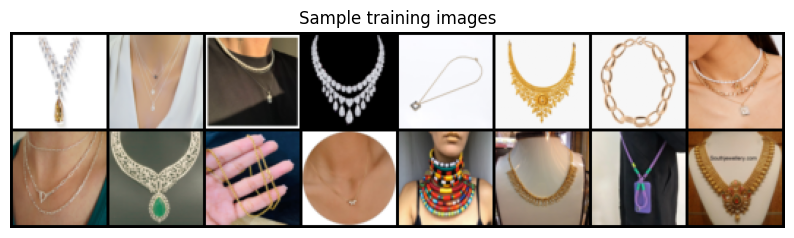

In [5]:
def show_grid(tensor, nrow=8, title=None, figsize=(10, 5)):
    """Plot a grid of images. tensor shape: (N, 3, H, W) in [0, 1]."""
    grid = make_grid(tensor.clamp(0, 1), nrow=nrow, padding=2).permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=figsize)
    plt.imshow(grid)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

batch = next(iter(train_loader))
show_grid(batch[:16], nrow=8, title='Sample training images')

## 3. VAE architecture

A compact conv VAE for 64×64 RGB images.

- **Encoder**: 4 strided conv blocks (64→32→16→8→4) → flatten → two linear heads for `mu` and `log_var`.
- **Reparameterize**: `z = mu + sigma * eps`, `eps ~ N(0, I)` — lets gradients flow through sampling.
- **Decoder**: mirror of the encoder with transposed convs, ending in a sigmoid so outputs are in `[0, 1]`.

In [6]:
class ConvVAE(nn.Module):
    def __init__(self, image_size=64, latent_dim=64, base_ch=32):
        super().__init__()
        assert image_size == 64, 'This architecture is wired for 64x64; adjust conv strides to change.'
        self.latent_dim = latent_dim
        c1, c2, c3, c4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8
        self.enc = nn.Sequential(
            nn.Conv2d(3,  c1, 4, 2, 1), nn.BatchNorm2d(c1), nn.LeakyReLU(0.2, inplace=True),  # 32
            nn.Conv2d(c1, c2, 4, 2, 1), nn.BatchNorm2d(c2), nn.LeakyReLU(0.2, inplace=True),  # 16
            nn.Conv2d(c2, c3, 4, 2, 1), nn.BatchNorm2d(c3), nn.LeakyReLU(0.2, inplace=True),  # 8
            nn.Conv2d(c3, c4, 4, 2, 1), nn.BatchNorm2d(c4), nn.LeakyReLU(0.2, inplace=True),  # 4
        )
        self.flat_dim = c4 * 4 * 4
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self.flat_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(c4, c3, 4, 2, 1), nn.BatchNorm2d(c3), nn.ReLU(inplace=True),  # 8
            nn.ConvTranspose2d(c3, c2, 4, 2, 1), nn.BatchNorm2d(c2), nn.ReLU(inplace=True),  # 16
            nn.ConvTranspose2d(c2, c1, 4, 2, 1), nn.BatchNorm2d(c1), nn.ReLU(inplace=True),  # 32
            nn.ConvTranspose2d(c1, 3,  4, 2, 1), nn.Sigmoid(),                               # 64
        )
        self._base_ch = base_ch

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = self.fc_dec(z).view(-1, self._base_ch * 8, 4, 4)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=1.0):
    # Per-pixel reconstruction is summed then averaged over batch; KL is summed per sample then averaged.
    recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl, recon_loss, kl

# Sanity check.
_vae = ConvVAE(image_size=64, latent_dim=CFG['latent_dim']).to(DEVICE)
with torch.no_grad():
    _r, _mu, _lv = _vae(batch[:4].to(DEVICE))
print('recon:', tuple(_r.shape), 'mu:', tuple(_mu.shape), 'logvar:', tuple(_lv.shape))
del _vae, _r, _mu, _lv

recon: (4, 3, 64, 64) mu: (4, 64) logvar: (4, 64)


### 3a. VGG perceptual loss

MSE on raw pixels rewards the *average* plausible reconstruction — which looks blurry. A VGG16 feature-space loss rewards matching on *edges, shapes, textures*, so the decoder is pushed toward sharp, recognizable output. We combine pixel MSE (for stable coarse gradients) with VGG perceptual (for detail), plus the usual KL term weighted by `beta < 1`.

In [7]:
import torchvision.models as tvm

class VGGPerceptualLoss(nn.Module):
    """MSE on a handful of VGG16 feature maps. Inputs should be in [0,1]; ImageNet normalization happens here."""
    def __init__(self, layer_ids=(3, 8, 15, 22)):
        super().__init__()
        vgg = tvm.vgg16(weights=tvm.VGG16_Weights.IMAGENET1K_V1).features.eval()
        for p in vgg.parameters():
            p.requires_grad_(False)
        self.vgg = vgg
        self.layer_ids = set(layer_ids)
        self.last = max(layer_ids)
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def _features(self, x):
        x = (x - self.mean) / self.std
        feats = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.layer_ids:
                feats.append(x)
            if i >= self.last:
                break
        return feats

    def forward(self, a, b):
        fa, fb = self._features(a), self._features(b)
        return sum(F.mse_loss(x, y) for x, y in zip(fa, fb)) / len(fa)


perceptual = VGGPerceptualLoss().to(DEVICE)


def vae_loss_v2(recon, x, mu, logvar, *, beta=0.25, p_weight=1.0):
    """Combined pixel-MSE + VGG-perceptual reconstruction + KL."""
    recon_mse = F.mse_loss(recon, x, reduction='sum') / x.size(0)  # comparable scale to v1 (~200-1400)
    perc = perceptual(recon, x)                                    # scalar, typical range 0.5-5
    # Scale perceptual to the same order of magnitude as summed pixel MSE so p_weight is interpretable.
    perc_scaled = perc * x.shape[-1] * x.shape[-2]
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = recon_mse + p_weight * perc_scaled + beta * kl
    return total, recon_mse, perc_scaled, kl


# Sanity check — on one batch, verify the terms are on comparable scales.
with torch.no_grad():
    _vae = ConvVAE(image_size=64, latent_dim=CFG['latent_dim']).to(DEVICE)
    _r, _mu, _lv = _vae(batch[:8].to(DEVICE))
    _t, _m, _p, _k = vae_loss_v2(_r, batch[:8].to(DEVICE), _mu, _lv,
                                 beta=CFG['beta'], p_weight=CFG['perceptual_weight'])
print(f'mse {_m.item():.1f}  perceptual {_p.item():.1f}  kl {_k.item():.1f}  total {_t.item():.1f}')
del _vae, _r, _mu, _lv, _t, _m, _p, _k

mse 2038.5  perceptual 56627.8  kl 8.0  total 58670.2


## 4. Training

In [8]:
def train_vae(model, train_loader, val_loader, *, epochs, lr, beta, p_weight,
              device, log_every=5):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train': [], 'val': [], 'mse': [], 'perc': [], 'kl': []}
    for epoch in range(1, epochs + 1):
        model.train()
        tl = tm = tp = tk = 0.0; n = 0
        for x in train_loader:
            x = x.to(device)
            opt.zero_grad()
            recon, mu, logvar = model(x)
            loss, m, p, k = vae_loss_v2(recon, x, mu, logvar, beta=beta, p_weight=p_weight)
            loss.backward()
            opt.step()
            bs = x.size(0)
            tl += loss.item() * bs; tm += m.item() * bs; tp += p.item() * bs; tk += k.item() * bs; n += bs
        train_loss = tl / n; mse_avg = tm / n; perc_avg = tp / n; kl_avg = tk / n

        model.eval()
        vl = 0.0; n = 0
        with torch.no_grad():
            for x in val_loader:
                x = x.to(device)
                recon, mu, logvar = model(x)
                loss, _, _, _ = vae_loss_v2(recon, x, mu, logvar, beta=beta, p_weight=p_weight)
                vl += loss.item() * x.size(0); n += x.size(0)
        val_loss = vl / max(n, 1)

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        history['mse'].append(mse_avg)
        history['perc'].append(perc_avg)
        history['kl'].append(kl_avg)
        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            print(f'epoch {epoch:3d}  train {train_loss:8.1f}  val {val_loss:8.1f}  '
                  f'mse {mse_avg:7.1f}  perc {perc_avg:7.1f}  kl {kl_avg:6.2f}')
    return history

In [9]:
model = ConvVAE(image_size=CFG['image_size'], latent_dim=CFG['latent_dim']).to(DEVICE)
history = train_vae(model, train_loader, val_loader,
                    epochs=CFG['epochs'], lr=CFG['lr'],
                    beta=CFG['beta'], p_weight=CFG['perceptual_weight'],
                    device=DEVICE)

/Users/anvimehta/Desktop/USA/Northwestern/Spring 26/MSAI xx - Gen AI/jewelry-design-ai/.venv/lib/python3.14/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch   1  train  51247.4  val  40699.8  mse  1591.5  perc 44800.1  kl 9711.48
epoch   5  train  39220.6  val  40253.9  mse  1490.6  perc 37658.9  kl 142.32
epoch  10  train  38548.3  val  39173.2  mse  1457.8  perc 37041.7  kl  97.72
epoch  15  train  37827.5  val  38784.5  mse  1406.9  perc 36360.7  kl 119.91
epoch  20  train  36717.6  val  38444.1  mse  1372.7  perc 35266.9  kl 155.78
epoch  25  train  36112.0  val  38269.2  mse  1334.7  perc 34679.1  kl 196.45
epoch  30  train  35035.5  val  37674.1  mse  1337.1  perc 33588.5  kl 219.83
epoch  35  train  33778.2  val  37328.9  mse  1307.7  perc 32347.6  kl 245.82
epoch  40  train  32409.4  val  36429.1  mse  1280.0  perc 30998.3  kl 262.23
epoch  45  train  31808.3  val  36243.2  mse  1228.2  perc 30440.3  kl 279.46
epoch  50  train  30618.4  val  36607.3  mse  1221.8  perc 29241.1  kl 311.01
epoch  55  train  29350.1  val  35934.9  mse  1208.8  perc 27973.5  kl 335.72
epoch  60  train  28846.1  val  35931.2  mse  1194.4  perc 2748

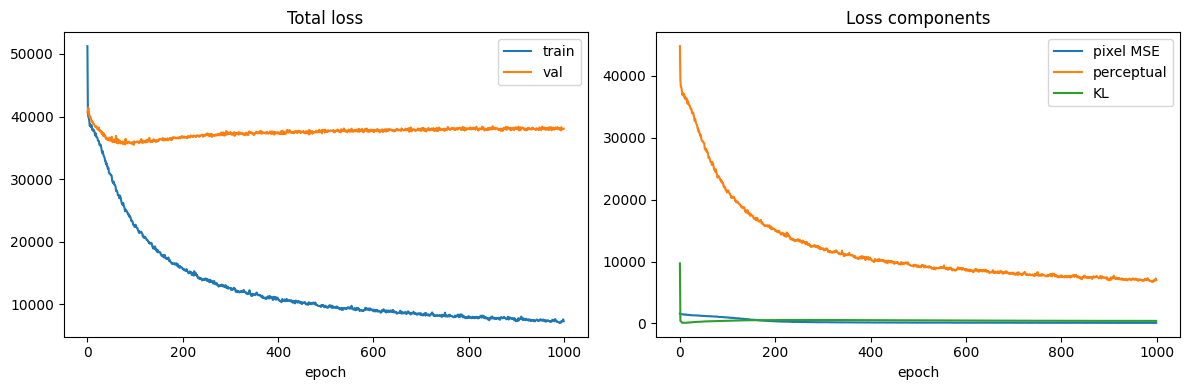

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train'], label='train')
ax[0].plot(history['val'], label='val')
ax[0].set_title('Total loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history['mse'],  label='pixel MSE')
ax[1].plot(history['perc'], label='perceptual')
ax[1].plot(history['kl'],   label='KL')
ax[1].set_title('Loss components'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Qualitative evaluation

1. **Reconstructions** — how faithfully the VAE rebuilds held-out images (good reconstructions ⇒ the encoder captured useful structure).
2. **Random samples** — designs drawn from the prior `N(0, I)` through the decoder (good samples ⇒ the latent space is populated with plausible designs).

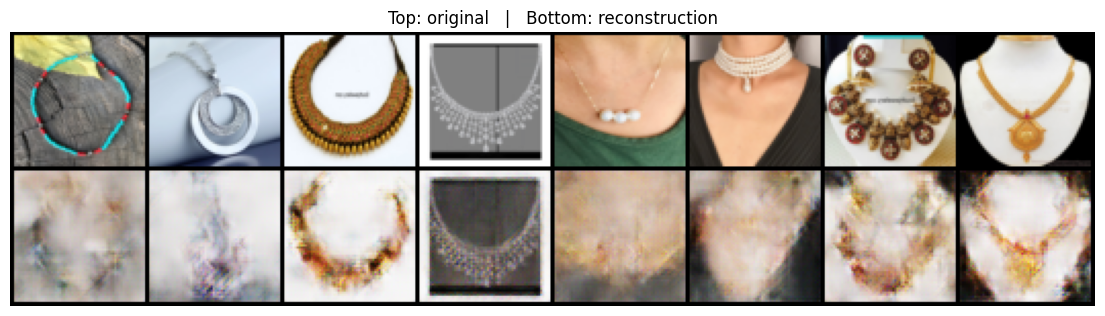

In [11]:
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x = next(iter(loader))[:n].to(device)
    with torch.no_grad():
        recon, _, _ = model(x)
    pairs = torch.cat([x, recon], dim=0)  # originals on top, reconstructions on bottom
    show_grid(pairs, nrow=n, title='Top: original   |   Bottom: reconstruction', figsize=(14, 4))

show_reconstructions(model, val_loader, DEVICE, n=8)

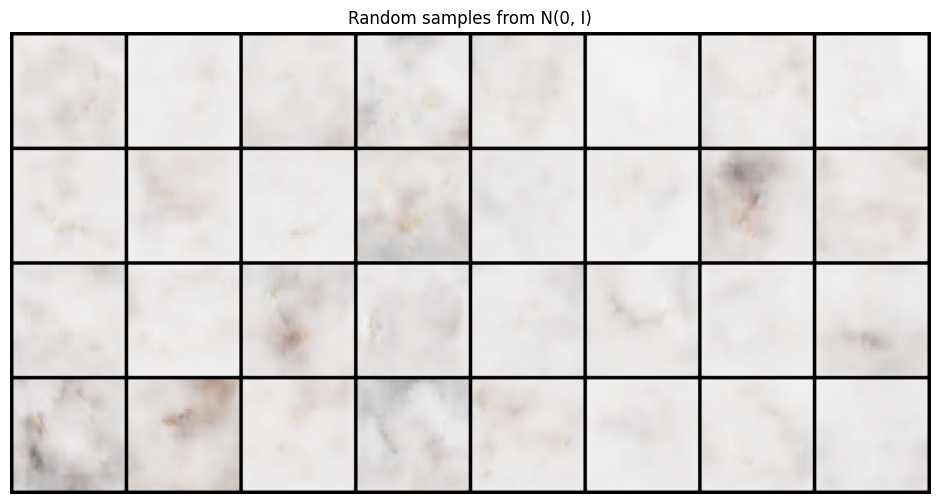

In [12]:
def sample_prior(model, n=32, device=DEVICE):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim, device=device)
        return model.decode(z)

samples = sample_prior(model, n=32)
show_grid(samples, nrow=8, title='Random samples from N(0, I)', figsize=(14, 6))

### 5a. Sampling from the empirical posterior

If the encoder packed information into regions the prior `N(0, I)` doesn't visit often, prior samples look bad even when reconstructions are sharp. Workaround: encode the training set to get the posterior means, fit a diagonal Gaussian to them, and sample from *that* instead. This uses the decoder as-is and usually gives the sharpest generations the model can produce.

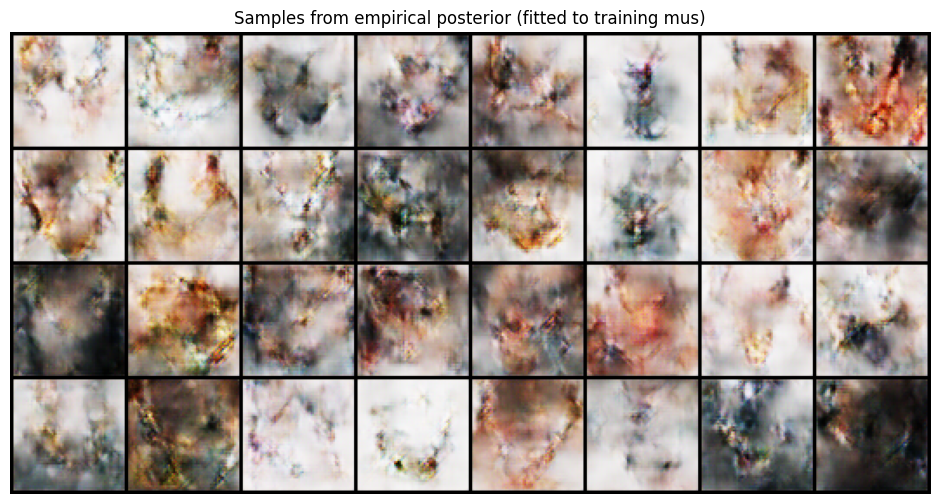

In [13]:
def sample_posterior(model, loader, n=32, device=DEVICE, temperature=1.0):
    """Encode everything in `loader` to get posterior means, fit a diagonal Gaussian, sample from it."""
    model.eval()
    mus = []
    with torch.no_grad():
        for x in loader:
            mu, _ = model.encode(x.to(device))
            mus.append(mu)
        mus = torch.cat(mus, dim=0)
        mean = mus.mean(dim=0)
        std = mus.std(dim=0) * temperature
        z = mean + std * torch.randn(n, model.latent_dim, device=device)
        return model.decode(z)


post_samples = sample_posterior(model, train_loader, n=32)
show_grid(post_samples, nrow=8,
          title='Samples from empirical posterior (fitted to training mus)',
          figsize=(14, 6))

## 6. Exploring the latent space

Two classic probes:

- **Interpolation** — pick two real necklaces, encode to `z_a, z_b`, decode a straight-line walk between them. Smooth transitions ⇒ the latent space is continuous rather than memorized.
- **Per-dimension traversal** — hold `z` fixed and sweep one dimension to hint at what each coordinate controls (length? pendant size? color?).

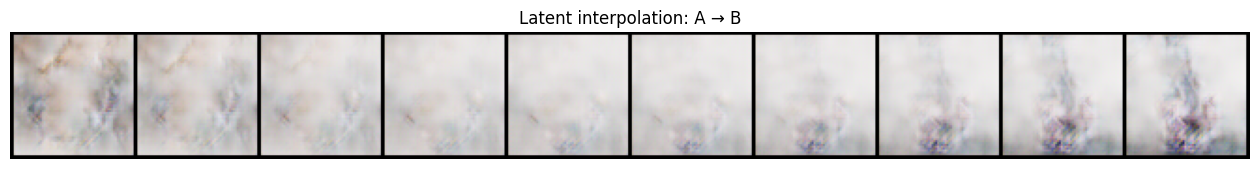

In [14]:
def interpolate(model, x_a, x_b, steps=10, device=DEVICE):
    model.eval()
    with torch.no_grad():
        mu_a, _ = model.encode(x_a.unsqueeze(0).to(device))
        mu_b, _ = model.encode(x_b.unsqueeze(0).to(device))
        ts = torch.linspace(0, 1, steps, device=device).view(-1, 1)
        zs = (1 - ts) * mu_a + ts * mu_b
        return model.decode(zs)

val_batch = next(iter(val_loader))
a, b = val_batch[0], val_batch[1]
interp = interpolate(model, a, b, steps=10)
show_grid(interp, nrow=10, title='Latent interpolation: A → B', figsize=(16, 2))

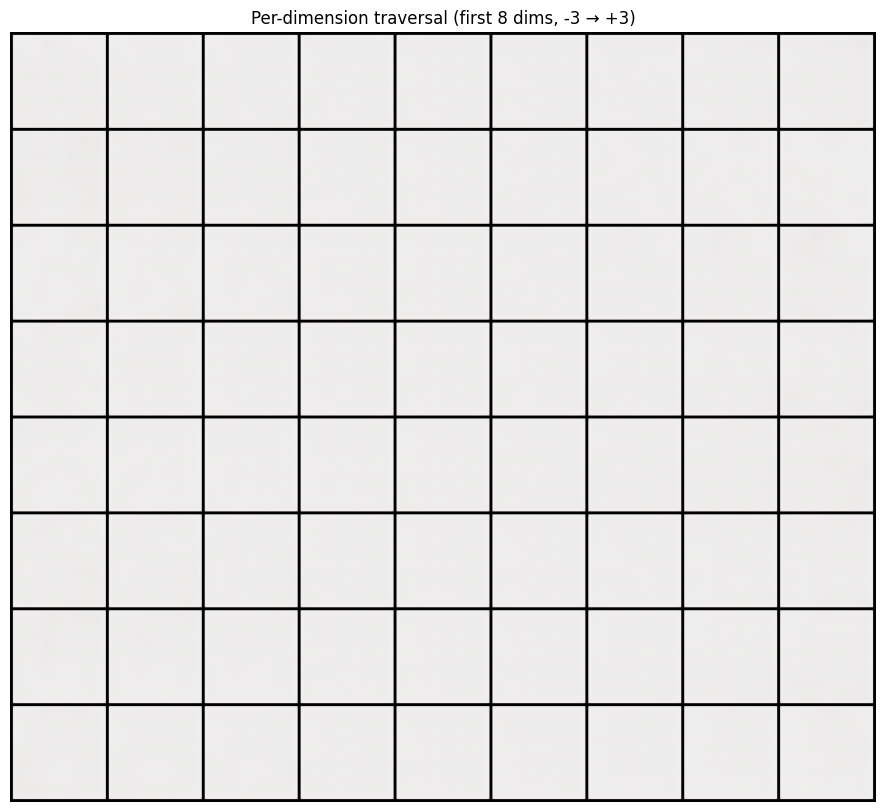

In [15]:
def latent_traversal(model, dims=8, steps=9, span=3.0, device=DEVICE):
    """For each of the first `dims` latent coords, sweep it from -span..+span with the rest at 0."""
    model.eval()
    with torch.no_grad():
        vals = torch.linspace(-span, span, steps, device=device)
        rows = []
        for d in range(dims):
            z = torch.zeros(steps, model.latent_dim, device=device)
            z[:, d] = vals
            rows.append(model.decode(z))
        return torch.cat(rows, dim=0), dims, steps

imgs, dims, steps = latent_traversal(model, dims=8, steps=9, span=3.0)
show_grid(imgs, nrow=steps, title=f'Per-dimension traversal (first {dims} dims, -3 → +3)', figsize=(16, 10))

## 7. Hyperparameter sweep

A small grid over `latent_dim` and `learning_rate` to see how each affects final loss and sample quality. Epochs are kept low here so the sweep finishes quickly — the goal is a comparative view, not a fully-trained model per cell.

Expected trends:
- Too-small `latent_dim` → blurry, low-variety samples.
- Too-large `latent_dim` → more capacity but KL pushes many dims toward the prior (posterior collapse).
- LR too high → unstable loss; too low → under-trained in a fixed epoch budget.

In [16]:
# Shrunk sweep: we keep it small to focus compute on the longer main run.
# (The v1 notebook ran a 3x2 grid — its sample comparison is in outputs_v1/07_sweep_samples.png.)
SWEEP_EPOCHS = 15
latent_dims = [32, 128]
lrs = [1e-3]

sweep_results = {}
for ld in latent_dims:
    for lr in lrs:
        print(f'\n=== latent_dim={ld}  lr={lr} ===')
        m = ConvVAE(image_size=CFG['image_size'], latent_dim=ld).to(DEVICE)
        h = train_vae(m, train_loader, val_loader,
                      epochs=SWEEP_EPOCHS, lr=lr,
                      beta=CFG['beta'], p_weight=CFG['perceptual_weight'],
                      device=DEVICE, log_every=SWEEP_EPOCHS)
        sweep_results[(ld, lr)] = {'model': m, 'history': h}


=== latent_dim=32  lr=0.001 ===
epoch   1  train  54347.7  val  40779.5  mse  1734.4  perc 45135.3  kl 14956.10
epoch  15  train  38066.3  val  39364.3  mse  1458.4  perc 36566.7  kl  82.23

=== latent_dim=128  lr=0.001 ===
epoch   1  train  46242.2  val  40501.2  mse  1510.2  perc 43773.0  kl 1917.84
epoch  15  train  37379.8  val  38675.3  mse  1318.4  perc 35963.8  kl 195.36


latent_dim       lr   final_val   final_mse   final_perc   final_kl
        32    1e-03     39364.3      1458.4      36566.7      82.23
       128    1e-03     38675.3      1318.4      35963.8     195.36


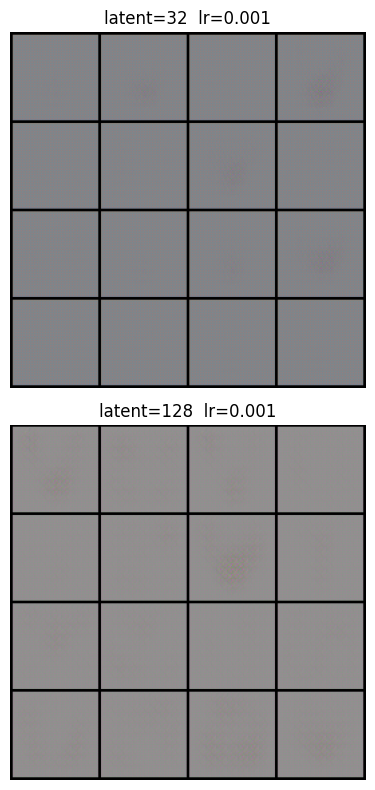

In [17]:
print(f"{'latent_dim':>10}  {'lr':>7}  {'final_val':>10}  {'final_mse':>10}  {'final_perc':>11}  {'final_kl':>9}")
for (ld, lr), r in sweep_results.items():
    h = r['history']
    print(f'{ld:>10}  {lr:>7.0e}  {h["val"][-1]:>10.1f}  {h["mse"][-1]:>10.1f}  {h["perc"][-1]:>11.1f}  {h["kl"][-1]:>9.2f}')

fig, axes = plt.subplots(len(latent_dims), len(lrs), figsize=(4 * len(lrs), 4 * len(latent_dims)),
                         squeeze=False)
for i, ld in enumerate(latent_dims):
    for j, lr in enumerate(lrs):
        m = sweep_results[(ld, lr)]['model']
        s = sample_prior(m, n=16, device=DEVICE)
        grid = make_grid(s.clamp(0, 1), nrow=4, padding=2).permute(1, 2, 0).cpu().numpy()
        ax = axes[i][j]
        ax.imshow(grid); ax.axis('off')
        ax.set_title(f'latent={ld}  lr={lr:g}')
plt.tight_layout(); plt.show()

## 8. Save the trained model

In [18]:
ckpt_dir = Path('checkpoints'); ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / f'v3_vae_latent{CFG["latent_dim"]}_ep{CFG["epochs"]}.pt'
torch.save({'state_dict': model.state_dict(), 'cfg': CFG}, ckpt_path)
print('Saved to', ckpt_path)

Saved to checkpoints/v3_vae_latent64_ep1000.pt


## 9. DDPM diffusion model

The VAE above hits the classic ceiling: reconstructions are okay, but prior samples are blank/blurry because the encoder doesn't tile the prior densely. Switching to a denoising diffusion model fixes this — there's no posterior to collapse, and the training objective (predict the noise added to a clean image at a random timestep) is a sharper learning signal than reconstruction MSE.

What we add:
- **UNet** with sinusoidal timestep embedding, GroupNorm + SiLU residual blocks, and a self-attention layer at the lowest spatial resolution.
- **Cosine noise schedule** (Nichol & Dhariwal, 2021) — gentler than the original linear schedule and noticeably better with limited data.
- **EMA weights** — sampling uses an exponential moving average of model parameters; standard practice for diffusion and important for sample quality.
- **DDIM sampling** — deterministic 50-step sampler instead of the 1000-step DDPM ancestral chain, ~20× faster with comparable quality.

Data is rescaled to `[-1, 1]` for training (epsilon-prediction targets are zero-mean Gaussian and the symmetric range matches that better than `[0, 1]`).

In [19]:
import math
from copy import deepcopy


def timestep_embedding(t, dim):
    """Standard sinusoidal embedding of integer timesteps -> (B, dim)."""
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([args.cos(), args.sin()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_emb_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_emb_dim, out_ch)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, ch, heads=4, groups=8):
        super().__init__()
        assert ch % heads == 0
        self.heads = heads
        self.norm = nn.GroupNorm(groups, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.qkv(self.norm(x)).reshape(b, 3, self.heads, c // self.heads, h * w)
        q, k, v = qkv.unbind(dim=1)                              # each (b, heads, dh, hw)
        scale = (c // self.heads) ** -0.5
        attn = torch.softmax((q.transpose(-2, -1) @ k) * scale, dim=-1)  # (b, heads, hw, hw)
        out = (v @ attn.transpose(-2, -1)).reshape(b, c, h, w)
        return x + self.proj(out)


class UNet(nn.Module):
    """Small UNet for 64x64 RGB diffusion. ~6M params at base=64."""
    def __init__(self, in_ch=3, base=64, t_dim=128):
        super().__init__()
        self.t_dim = t_dim
        emb = t_dim * 4
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, emb), nn.SiLU(), nn.Linear(emb, emb))

        # Encoder: 64 -> 32 -> 16 -> 8
        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1)
        self.d1 = ResBlock(base, base, emb)
        self.down1 = nn.Conv2d(base, base * 2, 4, 2, 1)
        self.d2 = ResBlock(base * 2, base * 2, emb)
        self.down2 = nn.Conv2d(base * 2, base * 4, 4, 2, 1)
        self.d3 = ResBlock(base * 4, base * 4, emb)
        self.down3 = nn.Conv2d(base * 4, base * 4, 4, 2, 1)

        # Mid (with self-attention at 8x8)
        self.m1 = ResBlock(base * 4, base * 4, emb)
        self.attn = SelfAttention(base * 4)
        self.m2 = ResBlock(base * 4, base * 4, emb)

        # Decoder: 8 -> 16 -> 32 -> 64, with skip connections
        self.up3 = nn.ConvTranspose2d(base * 4, base * 4, 4, 2, 1)
        self.u3 = ResBlock(base * 4 + base * 4, base * 4, emb)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 4, 2, 1)
        self.u2 = ResBlock(base * 2 + base * 2, base * 2, emb)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 4, 2, 1)
        self.u1 = ResBlock(base + base, base, emb)

        self.out_norm = nn.GroupNorm(8, base)
        self.out_conv = nn.Conv2d(base, in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.t_mlp(timestep_embedding(t, self.t_dim))
        h0 = self.in_conv(x)
        h1 = self.d1(h0, t_emb)
        h2 = self.d2(self.down1(h1), t_emb)
        h3 = self.d3(self.down2(h2), t_emb)
        m = self.m1(self.down3(h3), t_emb)
        m = self.attn(m)
        m = self.m2(m, t_emb)
        u3 = self.u3(torch.cat([self.up3(m), h3], dim=1), t_emb)
        u2 = self.u2(torch.cat([self.up2(u3), h2], dim=1), t_emb)
        u1 = self.u1(torch.cat([self.up1(u2), h1], dim=1), t_emb)
        return self.out_conv(F.silu(self.out_norm(u1)))


# Sanity check.
_unet = UNet(base=32).to(DEVICE)
with torch.no_grad():
    _y = _unet(batch[:2].to(DEVICE) * 2 - 1, torch.tensor([10, 500], device=DEVICE))
print('unet out:', tuple(_y.shape), 'params:', f'{sum(p.numel() for p in _unet.parameters())/1e6:.2f}M')
del _unet, _y

unet out: (2, 3, 64, 64) params: 3.22M


In [20]:
class GaussianDiffusion:
    """Cosine-schedule DDPM with a DDIM sampler. Operates on data in [-1, 1]."""
    def __init__(self, T=1000, schedule='cosine', device='cpu'):
        self.T = T
        if schedule == 'cosine':
            # Nichol & Dhariwal 2021: alphas_cumprod = cos^2((t/T + s) / (1+s) * pi/2).
            s = 0.008
            x = torch.linspace(0, T, T + 1)
            acp = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
            acp = acp / acp[0]
            betas = (1 - acp[1:] / acp[:-1]).clamp(1e-4, 0.999)
        else:
            betas = torch.linspace(1e-4, 0.02, T)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        self.betas = betas.to(device)
        self.alphas_cumprod = alphas_cumprod.to(device)
        self.sqrt_acp = alphas_cumprod.sqrt().to(device)
        self.sqrt_one_minus_acp = (1 - alphas_cumprod).sqrt().to(device)

    def q_sample(self, x0, t, noise):
        """Forward diffusion: x_t = sqrt(acp_t) * x0 + sqrt(1 - acp_t) * noise."""
        return (self.sqrt_acp[t][:, None, None, None] * x0
                + self.sqrt_one_minus_acp[t][:, None, None, None] * noise)

    @torch.no_grad()
    def ddim_sample(self, model, n, image_size, steps=50, eta=0.0, device='cpu'):
        """Deterministic DDIM sampler (eta=0). Returns images in [-1, 1]."""
        model.eval()
        # Subsample T into `steps` indices and walk them backward.
        ts = torch.linspace(0, self.T - 1, steps, dtype=torch.long, device=device).flip(0)
        x = torch.randn(n, 3, image_size, image_size, device=device)
        for i, t in enumerate(ts):
            t_batch = torch.full((n,), int(t), dtype=torch.long, device=device)
            eps = model(x, t_batch)
            acp_t = self.alphas_cumprod[t]
            x0_pred = ((x - (1 - acp_t).sqrt() * eps) / acp_t.sqrt()).clamp(-1.0, 1.0)
            if i < len(ts) - 1:
                t_prev = ts[i + 1]
                acp_prev = self.alphas_cumprod[t_prev]
                sigma = eta * ((1 - acp_prev) / (1 - acp_t)).sqrt() * (1 - acp_t / acp_prev).sqrt()
                dir_xt = (1 - acp_prev - sigma ** 2).clamp(min=0).sqrt() * eps
                x = acp_prev.sqrt() * x0_pred + dir_xt + sigma * torch.randn_like(x)
            else:
                x = x0_pred
        return x


# Sanity check.
_diff = GaussianDiffusion(T=1000, device=DEVICE)
print(f'beta range: [{_diff.betas.min().item():.5f}, {_diff.betas.max().item():.5f}]')
print(f'alphas_cumprod[0]={_diff.alphas_cumprod[0].item():.4f}  '
      f'alphas_cumprod[-1]={_diff.alphas_cumprod[-1].item():.6f}')
del _diff

beta range: [0.00010, 0.99900]
alphas_cumprod[0]=0.9999  alphas_cumprod[-1]=0.000000


In [21]:
class EMA:
    """Exponential moving average of model parameters. Sampling uses EMA weights."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v, alpha=1 - self.decay)
            else:
                self.shadow[k].copy_(v)

    def copy_to(self, model):
        model.load_state_dict(self.shadow)


def train_diffusion(model, diffusion, train_loader, *, epochs, lr, device,
                    ema_decay=0.999, log_every=10):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ema = EMA(model, decay=ema_decay)
    losses = []
    for epoch in range(1, epochs + 1):
        model.train()
        ep_loss, n = 0.0, 0
        for x in train_loader:
            x = x.to(device) * 2 - 1                                  # [0,1] -> [-1,1]
            t = torch.randint(0, diffusion.T, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_t = diffusion.q_sample(x, t, noise)
            eps_pred = model(x_t, t)
            loss = F.mse_loss(eps_pred, noise)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # diffusion training likes a clipped grad
            opt.step()
            ema.update(model)
            ep_loss += loss.item() * x.size(0); n += x.size(0)
        losses.append(ep_loss / max(n, 1))
        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            print(f'epoch {epoch:4d}  loss {losses[-1]:.4f}')
    return losses, ema

UNet params: 11.14M
epoch    1  loss 0.8818
epoch   10  loss 0.1153
epoch   20  loss 0.0871
epoch   30  loss 0.0661
epoch   40  loss 0.0687
epoch   50  loss 0.0542
epoch   60  loss 0.0518
epoch   70  loss 0.0469
epoch   80  loss 0.0500
epoch   90  loss 0.0519
epoch  100  loss 0.0420
epoch  110  loss 0.0482
epoch  120  loss 0.0395
epoch  130  loss 0.0424
epoch  140  loss 0.0455
epoch  150  loss 0.0401
epoch  160  loss 0.0409
epoch  170  loss 0.0335
epoch  180  loss 0.0376
epoch  190  loss 0.0333
epoch  200  loss 0.0346
epoch  210  loss 0.0363
epoch  220  loss 0.0377
epoch  230  loss 0.0335
epoch  240  loss 0.0402
epoch  250  loss 0.0318
epoch  260  loss 0.0333
epoch  270  loss 0.0303
epoch  280  loss 0.0301
epoch  290  loss 0.0280
epoch  300  loss 0.0293
epoch  310  loss 0.0322
epoch  320  loss 0.0281
epoch  330  loss 0.0278
epoch  340  loss 0.0288
epoch  350  loss 0.0284
epoch  360  loss 0.0306
epoch  370  loss 0.0324
epoch  380  loss 0.0344
epoch  390  loss 0.0243
epoch  400  loss 0.0

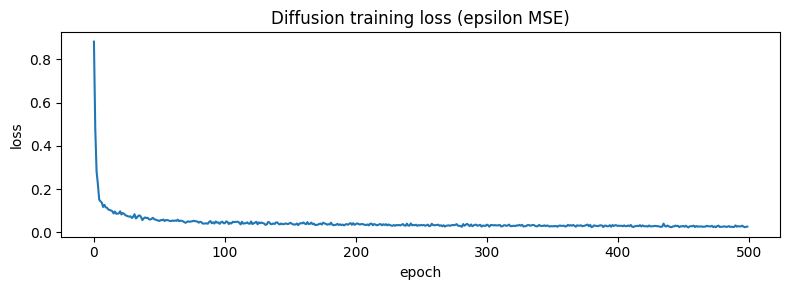

In [22]:
# Diffusion config. With ~470 images and batch 64 we only get ~7 batches/epoch,
# so we need many epochs to accumulate enough gradient updates. Plan for ~3500+ updates.
DIFF_CFG = dict(
    image_size=64,
    base_channels=64,
    timesteps=1000,
    epochs=500,
    lr=2e-4,
    ema_decay=0.999,
    schedule='cosine',
)

unet = UNet(in_ch=3, base=DIFF_CFG['base_channels']).to(DEVICE)
print(f'UNet params: {sum(p.numel() for p in unet.parameters())/1e6:.2f}M')

diffusion = GaussianDiffusion(T=DIFF_CFG['timesteps'], schedule=DIFF_CFG['schedule'], device=DEVICE)

diff_losses, diff_ema = train_diffusion(
    unet, diffusion, train_loader,
    epochs=DIFF_CFG['epochs'],
    lr=DIFF_CFG['lr'],
    device=DEVICE,
    ema_decay=DIFF_CFG['ema_decay'],
)

plt.figure(figsize=(8, 3))
plt.plot(diff_losses)
plt.title('Diffusion training loss (epsilon MSE)')
plt.xlabel('epoch'); plt.ylabel('loss')
plt.tight_layout(); plt.show()

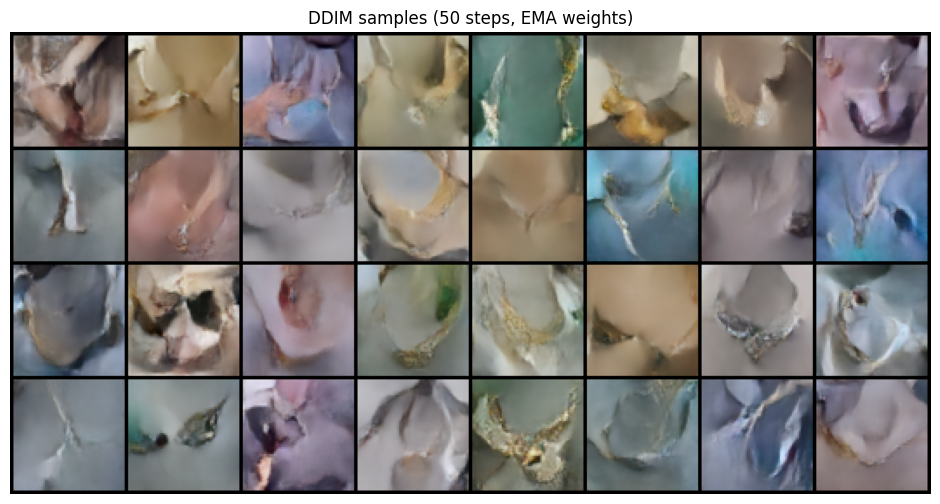

In [23]:
# Sample with EMA weights (sharper than online weights, especially with limited data).
ema_unet = UNet(in_ch=3, base=DIFF_CFG['base_channels']).to(DEVICE)
diff_ema.copy_to(ema_unet)
ema_unet.eval()

samples = diffusion.ddim_sample(
    ema_unet, n=32, image_size=DIFF_CFG['image_size'], steps=50, eta=0.0, device=DEVICE,
)
samples = (samples + 1) / 2  # back to [0, 1] for display

show_grid(samples, nrow=8, title='DDIM samples (50 steps, EMA weights)', figsize=(14, 6))

In [24]:
ckpt_dir = Path('checkpoints'); ckpt_dir.mkdir(exist_ok=True)
diff_ckpt_path = ckpt_dir / f'ddpm_unet_b{DIFF_CFG["base_channels"]}_ep{DIFF_CFG["epochs"]}.pt'
torch.save({
    'state_dict': unet.state_dict(),
    'ema_state_dict': diff_ema.shadow,
    'cfg': DIFF_CFG,
}, diff_ckpt_path)
print('Saved to', diff_ckpt_path)

Saved to checkpoints/ddpm_unet_b64_ep500.pt


## 10. Notes & next steps

Things worth trying once the baseline is working:
- **β-VAE**: raise `beta` above 1 to push for more disentangled latent dimensions (cleaner traversals at the cost of blurrier reconstructions).
- **Bigger images**: bump `image_size` to 128 and add one more conv stage (and one more diffusion down/up stage).
- **More diffusion training**: with ~470 images this dataset is tiny for diffusion — push `DIFF_CFG['epochs']` higher (1000–2000) if samples still look noisy.
- **Classifier-free guidance**: if you add metadata (pendant / chain / choker), encode it as a conditioning vector and add a small CFG dropout during training; sample with guidance scale ~3.
- **Switch to v-prediction**: often more stable than epsilon-prediction with cosine schedules.